<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

## Step 2. Import the dataset

In [2]:
df = pd.read_csv("50_Startups.csv")

In [3]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [12]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [13]:
x = df.iloc[::,:4:]
y = df.iloc[::,4::]
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [23]:
x1 = pd.get_dummies(x,columns=['State'],drop_first=True)

In [24]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [11]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [27]:
from sklearn.model_selection import train_test_split

x1_train,x1_test,y_train,y_test = train_test_split(x1,y,test_size=0.2,random_state=42)

print(x1_train.shape)
print(x1_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 5)
(10, 5)
(40, 1)
(10, 1)


## Step 8  Import LinearRegression model from linear_model family 

In [29]:
from sklearn.linear_model import LinearRegression

## Step 9  Fit the data

In [30]:
model = LinearRegression()
model.fit(x1_train,y_train)

LinearRegression()

## Step 10  Predict the data

In [31]:
y_predict = model.predict(x1_test)

## Step 11  Display Result

In [19]:
# y_test and y_predict

In [32]:
import matplotlib.pyplot as plt

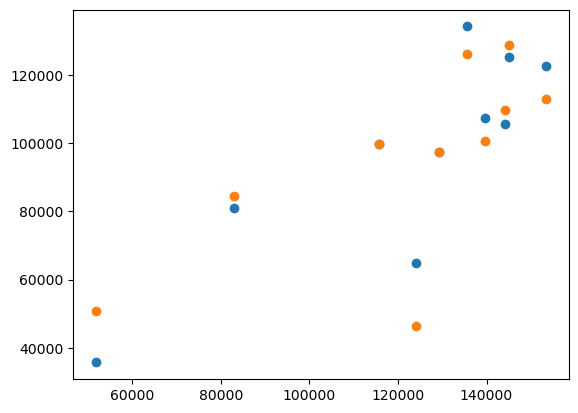

In [33]:
plt.scatter(x1_test['Administration'],y_test)
plt.scatter(x1_test['Administration'],y_predict)

## RSS

In [35]:
from sklearn.metrics import mean_squared_error

rss = mean_squared_error(y_test, y_predict) * len(y_test)
print("RSS:", rss)

RSS: 820103630.4430102


In [36]:
RSS = np.sum((y_test - y_predict) ** 2)
RSS

D:\Anaconda\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Profit    8.201036e+08
dtype: float64

## R Square

In [38]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_predict)
print("R² Score:", r2)

R² Score: 0.8987266414328637


In [39]:
import numpy as np

rss = np.sum((y_test - y_predict) ** 2)
tss = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (rss / tss)
print("R² Score:", r2)

R² Score: Profit    0.898727
dtype: float64


D:\Anaconda\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
